In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# =============================================================================
# 1. Define POS Tags and Vocabulary
# =============================================================================

# Specify the set of POS tags
POS_TAGS = ['DET', 'NOUN', 'VERB', 'ADJ', 'ADV', 'PREP', 'PRON', 'CONJ']

# Define a simple vocabulary mapped to their possible POS tags
VOCABULARY = {
    # Determiners
    'the': ['DET'], 'a': ['DET'], 'an': ['DET'], 'this': ['DET'], 'that': ['DET'],
    # Nouns
    'dog': ['NOUN'], 'cat': ['NOUN'], 'book': ['NOUN'], 'house': ['NOUN'], 
    'car': ['NOUN'], 'man': ['NOUN'], 'woman': ['NOUN'], 'child': ['NOUN'],
    'time': ['NOUN'], 'way': ['NOUN'],
    # Verbs
    'runs': ['VERB'], 'eats': ['VERB'], 'reads': ['VERB'], 'is': ['VERB'],
    'was': ['VERB'], 'has': ['VERB'], 'goes': ['VERB'], 'sees': ['VERB'],
    'likes': ['VERB'], 'wants': ['VERB'],
    # Adjectives
    'big': ['ADJ'], 'small': ['ADJ'], 'red': ['ADJ'], 'blue': ['ADJ'],
    'happy': ['ADJ'], 'sad': ['ADJ'], 'old': ['ADJ'], 'new': ['ADJ'],
    # Adverbs
    'quickly': ['ADV'], 'slowly': ['ADV'], 'very': ['ADV'], 'really': ['ADV'],
    'always': ['ADV'], 'never': ['ADV'],
    # Prepositions
    'in': ['PREP'], 'on': ['PREP'], 'at': ['PREP'], 'with': ['PREP'],
    'to': ['PREP'], 'from': ['PREP'],
    # Pronouns
    'he': ['PRON'], 'she': ['PRON'], 'it': ['PRON'], 'they': ['PRON'],
    'we': ['PRON'], 'I': ['PRON'],
    # Conjunctions
    'and': ['CONJ'], 'but': ['CONJ'], 'or': ['CONJ'],
}


In [5]:

# =============================================================================
# 2. Generate a Corpus with Tagged Sentences
# =============================================================================

def generate_sentence():
    """Generate a random sentence following simple grammar patterns."""
    patterns = [
        ['DET', 'NOUN', 'VERB'],
        ['DET', 'ADJ', 'NOUN', 'VERB'],
        ['PRON', 'VERB', 'DET', 'NOUN'],
        ['DET', 'NOUN', 'VERB', 'ADV'],
        ['DET', 'ADJ', 'NOUN', 'VERB', 'PREP', 'DET', 'NOUN'],
        ['PRON', 'ADV', 'VERB', 'DET', 'ADJ', 'NOUN'],
        ['DET', 'NOUN', 'CONJ', 'DET', 'NOUN', 'VERB'],
        ['PRON', 'VERB', 'ADJ', 'CONJ', 'ADJ'],
    ]
    
    pattern = random.choice(patterns)
    sentence = []
    
    for tag in pattern:
        # Find words that can have this tag
        possible_words = [word for word, tags in VOCABULARY.items() if tag in tags]
        word = random.choice(possible_words)
        sentence.append((word, tag))
    
    return sentence

def generate_corpus(num_sentences=100):
    """Generate a corpus of tagged sentences."""
    corpus = []
    for _ in range(num_sentences):
        corpus.append(generate_sentence())
    return corpus


In [6]:

# =============================================================================
# 3. Estimate HMM Parameters using Relative Frequencies
# =============================================================================

class HMMParameterEstimator:
    """Estimate HMM parameters from a tagged corpus using relative frequencies."""
    
    def __init__(self, pos_tags):
        self.pos_tags = pos_tags
        self.tag_to_idx = {tag: idx for idx, tag in enumerate(pos_tags)}
        self.num_tags = len(pos_tags)
        
        # Initialize count matrices
        self.transition_counts = np.zeros((self.num_tags, self.num_tags))
        self.emission_counts = defaultdict(lambda: np.zeros(self.num_tags))
        self.initial_counts = np.zeros(self.num_tags)
        
        # Parameter matrices (to be computed)
        self.transition_probs = None
        self.emission_probs = None
        self.initial_probs = None
        self.vocabulary = set()
    
    def count_from_corpus(self, corpus):
        """Count occurrences from the tagged corpus."""
        for sentence in corpus:
            if len(sentence) == 0:
                continue
            
            # Count initial state
            first_tag = sentence[0][1]
            self.initial_counts[self.tag_to_idx[first_tag]] += 1
            
            # Count transitions and emissions
            for i, (word, tag) in enumerate(sentence):
                tag_idx = self.tag_to_idx[tag]
                self.vocabulary.add(word)
                
                # Emission count
                self.emission_counts[word][tag_idx] += 1
                
                # Transition count (if not the last word)
                if i < len(sentence) - 1:
                    next_tag = sentence[i + 1][1]
                    next_tag_idx = self.tag_to_idx[next_tag]
                    self.transition_counts[tag_idx][next_tag_idx] += 1
    
    def estimate_parameters(self):
        """Estimate probabilities using relative frequencies (MLE)."""
        # Initial probabilities: P(tag) = count(tag as first) / total sentences
        total_initial = np.sum(self.initial_counts)
        if total_initial > 0:
            self.initial_probs = self.initial_counts / total_initial
        else:
            self.initial_probs = np.ones(self.num_tags) / self.num_tags
        
        # Transition probabilities: P(tag_j | tag_i) = count(tag_i -> tag_j) / count(tag_i ->)
        self.transition_probs = np.zeros((self.num_tags, self.num_tags))
        for i in range(self.num_tags):
            row_sum = np.sum(self.transition_counts[i])
            if row_sum > 0:
                self.transition_probs[i] = self.transition_counts[i] / row_sum
            else:
                # Uniform distribution if no transitions observed
                self.transition_probs[i] = np.ones(self.num_tags) / self.num_tags
        
        # Emission probabilities: P(word | tag) = count(word, tag) / count(tag)
        tag_counts = np.zeros(self.num_tags)
        for word in self.vocabulary:
            tag_counts += self.emission_counts[word]
        
        self.emission_probs = {}
        for word in self.vocabulary:
            self.emission_probs[word] = np.zeros(self.num_tags)
            for tag_idx in range(self.num_tags):
                if tag_counts[tag_idx] > 0:
                    self.emission_probs[word][tag_idx] = (
                        self.emission_counts[word][tag_idx] / tag_counts[tag_idx]
                    )
        
        return self.initial_probs, self.transition_probs, self.emission_probs
    
    def print_parameters(self):
        """Print the estimated parameters."""
        print("=" * 60)
        print("ESTIMATED HMM PARAMETERS")
        print("=" * 60)
        
        print("\n1. INITIAL STATE PROBABILITIES (π)")
        print("-" * 40)
        for tag, prob in zip(self.pos_tags, self.initial_probs):
            print(f"   P(start={tag:6s}) = {prob:.4f}")
        
        print("\n2. TRANSITION PROBABILITIES (A)")
        print("-" * 40)
        print("   Format: P(to_tag | from_tag)")
        print()
        
        # Print as a formatted table
        header = "From\\To  " + " ".join(f"{tag:>7s}" for tag in self.pos_tags)
        print(f"   {header}")
        print("   " + "-" * len(header))
        for i, from_tag in enumerate(self.pos_tags):
            row = f"   {from_tag:7s} "
            row += " ".join(f"{self.transition_probs[i][j]:7.3f}" for j in range(self.num_tags))
            print(row)
        
        print("\n3. EMISSION PROBABILITIES (B) - Sample")
        print("-" * 40)
        print("   Format: P(word | tag)")
        sample_words = list(self.vocabulary)[:10]
        for word in sample_words:
            print(f"\n   Word: '{word}'")
            for tag_idx, tag in enumerate(self.pos_tags):
                if self.emission_probs[word][tag_idx] > 0:
                    print(f"      P({word} | {tag}) = {self.emission_probs[word][tag_idx]:.4f}")


In [7]:

# =============================================================================
# 4. Visualize Transition Matrix
# =============================================================================

def visualize_transition_matrix(transition_probs, pos_tags, save_path='transition_matrix.png'):
    """Create a heatmap visualization of the transition matrix."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap
    ax1 = axes[0]
    im = ax1.imshow(transition_probs, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('Transition Probability', fontsize=12)
    
    # Set ticks and labels
    ax1.set_xticks(np.arange(len(pos_tags)))
    ax1.set_yticks(np.arange(len(pos_tags)))
    ax1.set_xticklabels(pos_tags, fontsize=10)
    ax1.set_yticklabels(pos_tags, fontsize=10)
    
    # Rotate x labels
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    
    # Add text annotations
    for i in range(len(pos_tags)):
        for j in range(len(pos_tags)):
            prob = transition_probs[i, j]
            text_color = 'white' if prob > 0.5 else 'black'
            ax1.text(j, i, f'{prob:.2f}', ha='center', va='center', 
                    color=text_color, fontsize=9, fontweight='bold')
    
    ax1.set_xlabel('To State (Next Tag)', fontsize=12)
    ax1.set_ylabel('From State (Current Tag)', fontsize=12)
    ax1.set_title('HMM Transition Probability Matrix\nP(next_tag | current_tag)', fontsize=14)
    
    # Bar chart of most likely transitions
    ax2 = axes[1]
    
    # Find the most likely next state for each state
    most_likely_transitions = []
    for i, from_tag in enumerate(pos_tags):
        max_idx = np.argmax(transition_probs[i])
        max_prob = transition_probs[i, max_idx]
        to_tag = pos_tags[max_idx]
        most_likely_transitions.append((from_tag, to_tag, max_prob))
    
    # Create grouped bar chart showing top transitions
    x = np.arange(len(pos_tags))
    colors = plt.cm.Set2(np.linspace(0, 1, len(pos_tags)))
    
    bars = ax2.bar(x, [t[2] for t in most_likely_transitions], color=colors, edgecolor='black')
    
    # Add labels on bars
    for i, (bar, transition) in enumerate(zip(bars, most_likely_transitions)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'→{transition[1]}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(pos_tags, fontsize=10)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_xlabel('From State (Current Tag)', fontsize=12)
    ax2.set_title('Most Likely Next State for Each POS Tag', fontsize=14)
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualization saved to: {save_path}")

def visualize_initial_probs(initial_probs, pos_tags):
    """Visualize initial state probabilities."""
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = plt.cm.Pastel1(np.linspace(0, 1, len(pos_tags)))
    bars = ax.bar(pos_tags, initial_probs, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, prob in zip(bars, initial_probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{prob:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_xlabel('POS Tag', fontsize=12)
    ax.set_title('Initial State Probabilities π\nP(first word has tag)', fontsize=14)
    ax.set_ylim(0, max(initial_probs) * 1.2)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('initial_probs.png', dpi=150, bbox_inches='tight')
    plt.show()


HMM PARAMETER ESTIMATION FROM CORPUS

1. POS TAGS USED: ['DET', 'NOUN', 'VERB', 'ADJ', 'ADV', 'PREP', 'PRON', 'CONJ']
   Number of tags: 8

2. GENERATING CORPUS...
   Generated 100 sentences
   Total words: 495

   Sample sentences from corpus:
   [1] Words: the happy house is
       Tags:  DET ADJ NOUN VERB
   [2] Words: I eats that cat
       Tags:  PRON VERB DET NOUN
   [3] Words: the dog and a house likes
       Tags:  DET NOUN CONJ DET NOUN VERB
   [4] Words: that house likes
       Tags:  DET NOUN VERB
   [5] Words: a child or an dog reads
       Tags:  DET NOUN CONJ DET NOUN VERB

3. ESTIMATING HMM PARAMETERS...
ESTIMATED HMM PARAMETERS

1. INITIAL STATE PROBABILITIES (π)
----------------------------------------
   P(start=DET   ) = 0.6700
   P(start=NOUN  ) = 0.0000
   P(start=VERB  ) = 0.0000
   P(start=ADJ   ) = 0.0000
   P(start=ADV   ) = 0.0000
   P(start=PREP  ) = 0.0000
   P(start=PRON  ) = 0.3300
   P(start=CONJ  ) = 0.0000

2. TRANSITION PROBABILITIES (A)
--------------

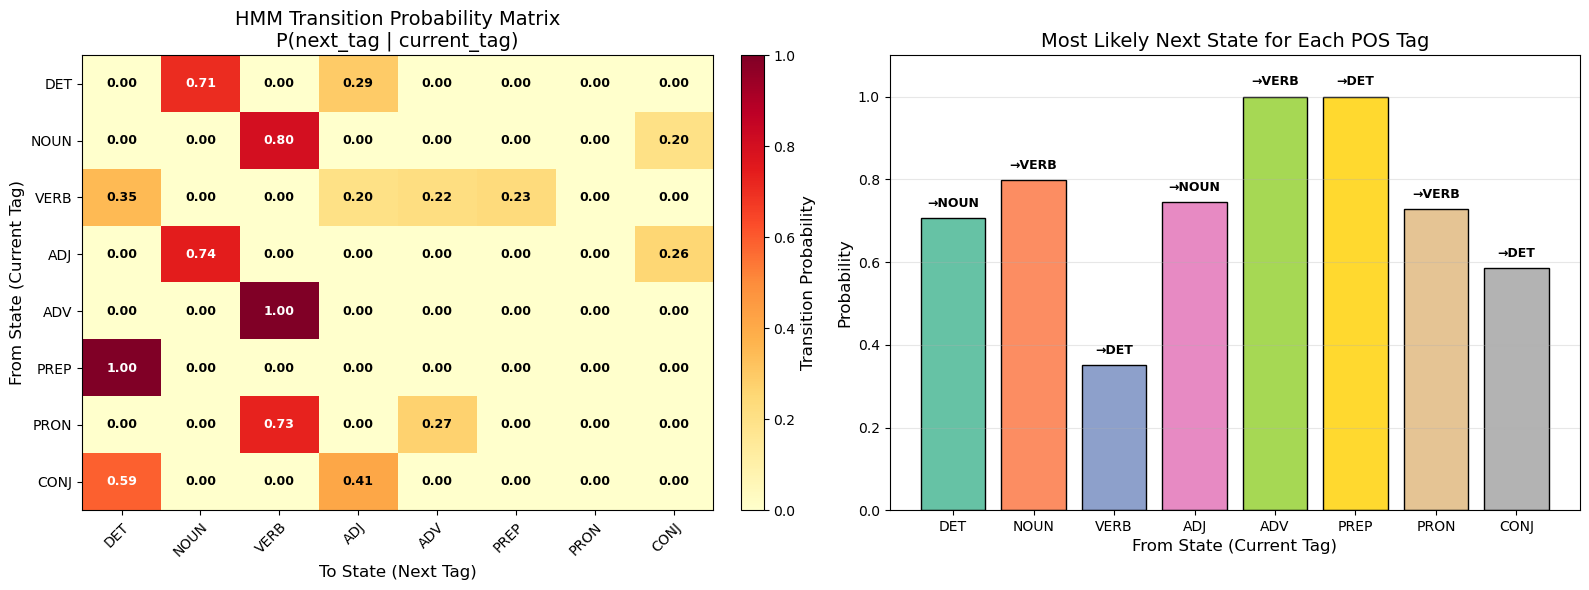


Visualization saved to: transition_matrix.png


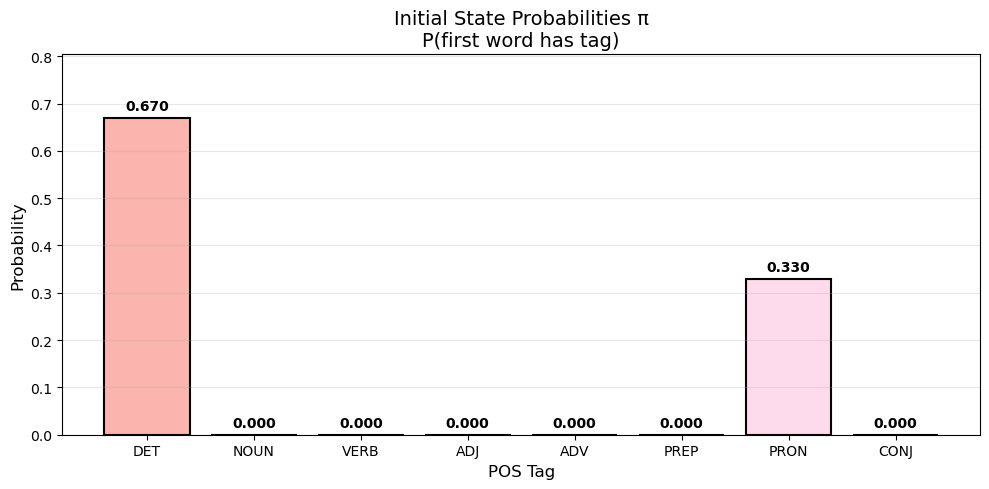


COMPLETE!


In [8]:

# =============================================================================
# 5. Main Execution
# =============================================================================

def main():
    print("=" * 60)
    print("HMM PARAMETER ESTIMATION FROM CORPUS")
    print("=" * 60)
    
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Step 1: Display POS tags
    print(f"\n1. POS TAGS USED: {POS_TAGS}")
    print(f"   Number of tags: {len(POS_TAGS)}")
    
    # Step 2: Generate corpus
    NUM_SENTENCES = 100
    print(f"\n2. GENERATING CORPUS...")
    corpus = generate_corpus(NUM_SENTENCES)
    
    total_words = sum(len(sent) for sent in corpus)
    print(f"   Generated {NUM_SENTENCES} sentences")
    print(f"   Total words: {total_words}")
    
    # Display sample sentences
    print("\n   Sample sentences from corpus:")
    for i, sentence in enumerate(corpus[:5]):
        words = ' '.join([word for word, tag in sentence])
        tags = ' '.join([tag for word, tag in sentence])
        print(f"   [{i+1}] Words: {words}")
        print(f"       Tags:  {tags}")
    
    # Step 3: Estimate HMM parameters
    print(f"\n3. ESTIMATING HMM PARAMETERS...")
    estimator = HMMParameterEstimator(POS_TAGS)
    estimator.count_from_corpus(corpus)
    initial_probs, transition_probs, emission_probs = estimator.estimate_parameters()
    
    # Print parameters
    estimator.print_parameters()
    
    # Step 4: Visualize
    print("\n4. VISUALIZING TRANSITION MATRIX...")
    visualize_transition_matrix(transition_probs, POS_TAGS)
    visualize_initial_probs(initial_probs, POS_TAGS)
    
    print("\n" + "=" * 60)
    print("COMPLETE!")
    print("=" * 60)
    
    return estimator

if __name__ == "__main__":
    estimator = main()